In [5]:
import py4cytoscape as p4c
import pandas as pd

In [6]:
p4c.cytoscape_ping()
p4c.cytoscape_version_info()

You are connected to Cytoscape!


{'apiVersion': 'v1',
 'cytoscapeVersion': '3.10.4',
 'automationAPIVersion': '1.13.0',
 'py4cytoscapeVersion': '1.13.0'}

Cria a rede com base em um objeto python

In [ ]:
nodes = pd.DataFrame(data={'id': ["node 0","node 1","node 2","node 3"], 'group': ["A","A","B","B"], 'score': [20,10,15,5]})
edges = pd.DataFrame(data={'source': ["node 0","node 0","node 0","node 2"], 'target': ["node 1","node 2","node 3","node 3"], 'interaction': ["inhibits","interacts","activates","interacts"], 'weight': [5.1,3.0,5.2,9.9]})

p4c.create_network_from_data_frames(nodes, edges, title="my first network", collection="DataFrame Example")

Applying default style...
Applying preferred layout


128

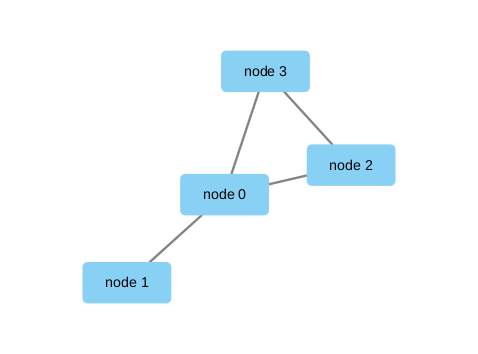

In [8]:
p4c.notebook_export_show_image()


### Troca de estilo

aplica o estilo Marquee

In [10]:
p4c.set_visual_style('Marquee')

{'message': 'Visual Style applied.'}

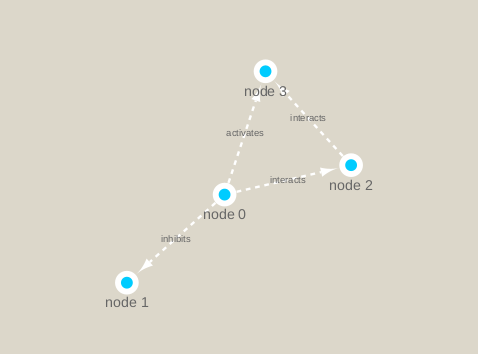

In [11]:
p4c.notebook_export_show_image()

### Estilo próprio
Cria um estilo próprio com atributos de nós, mapeamento de preenchimento e padrões


In [12]:
style_name = "myStyle"
defaults = {'NODE_SHAPE': "diamond", 'NODE_SIZE': 30, 'EDGE_TRANSPARENCY': 120, 'NODE_LABEL_POSITION': "W,E,c,0.00,0.00"}
nodeLabels = p4c.map_visual_property('node label', 'id', 'p') #'p' means 'passthrough' mapping
edgeWidth = p4c.map_visual_property('edge width', 'weight', 'p') #'p' means 'passthrough' mapping
p4c.create_visual_style(style_name, defaults, [nodeLabels, edgeWidth])
p4c.set_visual_style(style_name)

{'message': 'Visual Style applied.'}

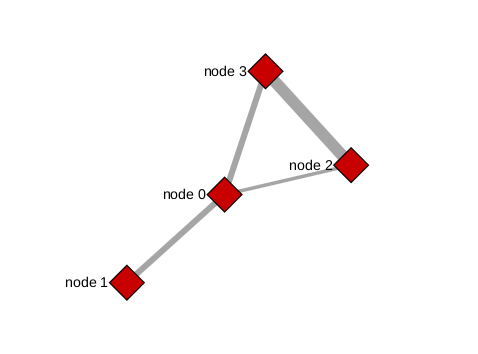

In [13]:
p4c.notebook_export_show_image()


py4cytoscape possui value generator functions. Isso facilita a associação automática de cores ou multiplos valores com atributos de nós (ou arestas)

In [14]:
from py4cytoscape import gen_node_color_map
from py4cytoscape import gen_edge_arrow_map
p4c.set_node_color_mapping(**gen_node_color_map('group', mapping_type='d', style_name=style_name)) #'d' means 'discrete' mapping
p4c.set_edge_target_arrow_shape_mapping(**gen_edge_arrow_map('interaction', style_name=style_name))

''

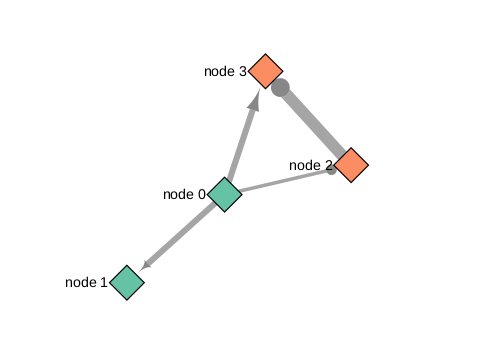

In [16]:
p4c.notebook_export_show_image()

para setar NODE_WIDTH e NODE_HEIGHT independentemente, preciso também desbloquear as dimensionalidades do nó

In [17]:
p4c.lock_node_dimensions(False, style_name)

{'views': [220]}

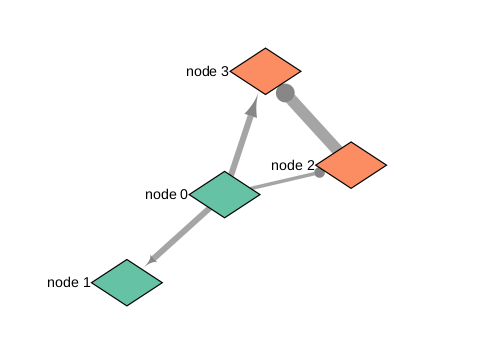

In [18]:
p4c.notebook_export_show_image()

### Exemplo de grafo biológico

Cria um **grafo de 4 nós**. Os atributos dos nós não foram incluidos nessa etapa

In [19]:
nodes = pd.DataFrame(data={'id': ["A", "B", "C", "D"]})
edges = pd.DataFrame(data={'source': ["C", "B", "B", "B"], 'target': ["D", "A", "D", "C"]})

p4c.create_network_from_data_frames(nodes, edges, title="simple network", collection="Biological Example")

Applying default style...
Applying preferred layout


289

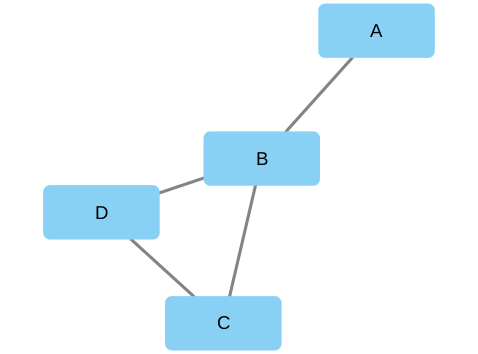

In [20]:
p4c.notebook_export_show_image()

#### Adicionando atributos dos nós
Nesse exemplo em específico, a proteína A fosforila B; A é uma kinase e B é um fator de transcrição. A expressão de mRNA deles (comparada com o controle) é uma log2 fold change de 1.8 e 3.0 respectivamente.

**É possível aplicar efeitos visuais em propriedades do grafo (ex: cor, tamanho e forma do nó)**

A meta será adicionar esses dois tipos de dados (moleculeType e log2fc)

In [ ]:
p4c.get_table_columns()

# pega a tabela de nós e arestas do Cytoscape, e mostra as colunas disponíveis


,SUID,shared name,name,selected,id
316,316,A,A,False,A
323,323,B,B,False,B
326,326,C,C,False,C
329,329,D,D,False,D


In [ ]:
df = pd.DataFrame(data={'moleculeType': ['kinase','TF','cytokine','cytokine'], 'log2fc': [1.8,3.0,-1.2,-2.5]})
df.index = ['A','B','C','D']
df

# Monta um df no pandas que vai ser integrado com a tabela de nós do Cytoscape. O índice do df deve ser o mesmo que a coluna 'id' da tabela de nós, para que o merge seja possível. O df pode conter as colunas que você quiser, e elas serão adicionadas à tabela de nós do Cytoscape.

,moleculeType,log2fc
A,kinase,1.8
B,TF,3.0
C,cytokine,-1.2
D,cytokine,-2.5


In [ ]:
p4c.load_table_data(df) 

# Carrega o df para o Cytoscape, integrando-o à tabela de nós. O índice do df é usado para fazer o merge com a coluna 'id' da tabela de nós. As colunas do df são adicionadas à tabela de nós do Cytoscape, e podem ser usadas para mapeamentos visuais ou análises.

'Success: Data loaded in defaultnode table'

In [24]:
p4c.get_table_columns()

,SUID,shared name,name,selected,id,moleculeType,log2fc,row.names
316,316,A,A,False,A,kinase,1.8,A
323,323,B,B,False,B,TF,3.0,B
326,326,C,C,False,C,cytokine,-1.2,C
329,329,D,D,False,D,cytokine,-2.5,D


### Modificação de visual, padrão e mapeamento

mudando o padrão

In [25]:
p4c.set_node_shape_default('OCTAGON')

style_name not specified, so updating "default" style.


''

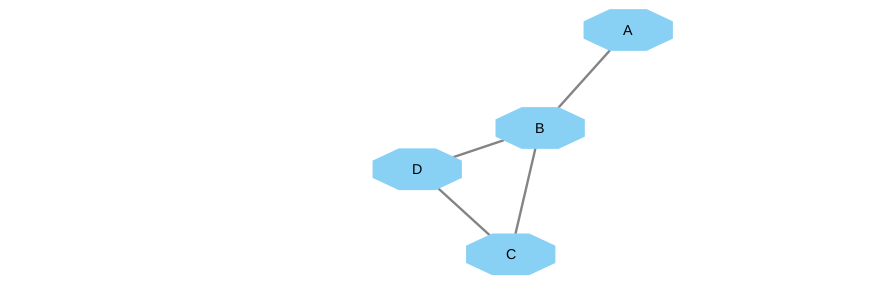

In [28]:
p4c.notebook_export_show_image()

mudando a cor

In [29]:
p4c.set_node_color_default('#AAFF88')

style_name not specified, so updating "default" style.


''

tamanho do nó

In [30]:
p4c.set_node_size_default(60)

style_name not specified, so updating "default" style.
style_name not specified, so updating "default" style.


''

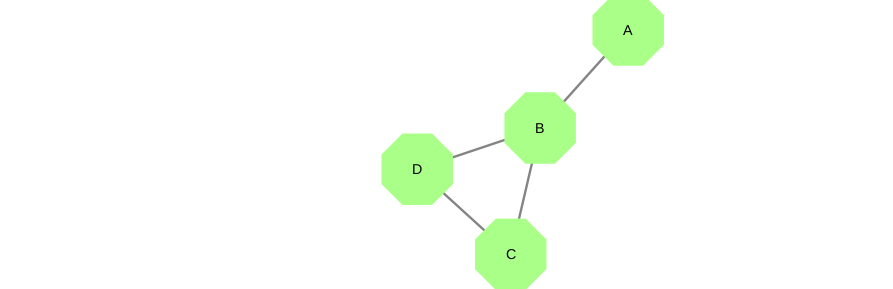

In [31]:
p4c.notebook_export_show_image()

muda o tamanho da fonte

In [32]:
p4c.set_node_font_size_default(30)

style_name not specified, so updating "default" style.


''

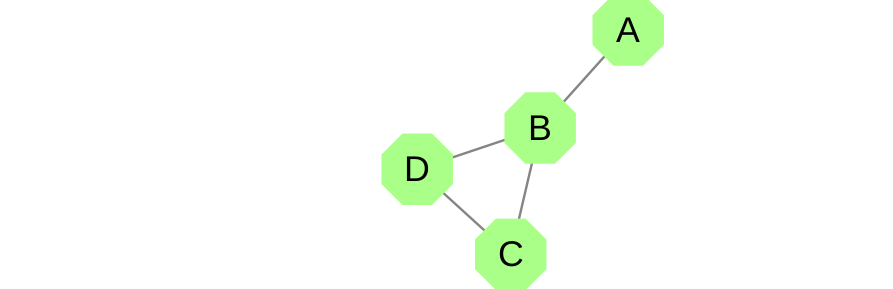

In [33]:
p4c.notebook_export_show_image()

mapear moleculeType nos formatos dos nós. Primeiro é possível ver todos os formatos disponíveis no cytoscape

In [34]:
p4c.get_node_shapes()

['OCTAGON',
 'DIAMOND',
 'TRIANGLE',
 'PARALLELOGRAM',
 'ELLIPSE',
 'ROUND_RECTANGLE',
 'VEE',
 'RECTANGLE',
 'HEXAGON']

In [35]:
p4c.get_table_columns()

,SUID,shared name,name,selected,id,moleculeType,log2fc,row.names
316,316,A,A,False,A,kinase,1.8,A
323,323,B,B,False,B,TF,3.0,B
326,326,C,C,False,C,cytokine,-1.2,C
329,329,D,D,False,D,cytokine,-2.5,D


In [36]:
column = 'moleculeType'
values = ['kinase', 'TF', 'cytokine']
shapes = ['DIAMOND', 'TRIANGLE', 'RECTANGLE']

p4c.set_node_shape_mapping(column, values, shapes)

style_name not specified, so updating "default" style.


''

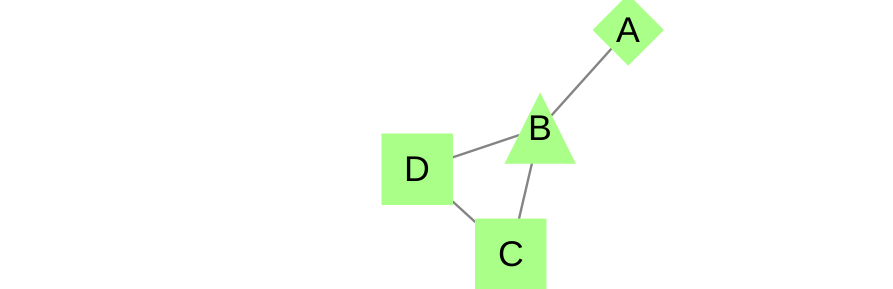

In [37]:
p4c.notebook_export_show_image()

O mapeamento de forma do nó é um exemplo de mapeamento discreto, onde um estilo é definido para cada valor discreto. Isso é util para dados categóricos (como tipo) onde existe apenas um número limitado de possibilidades.

**Também há outros tipos de mapeamentos, como o contínuo. No caso de valores de expressão, é preferível utilizar o mapeamento continuo -> o cytoscape fornece o gradiente de cores**

In [38]:
from py4cytoscape import palette_color_brewer_d_RdBu
p4c.set_node_color_mapping(**gen_node_color_map('log2fc', palette_color_brewer_d_RdBu()))

style_name not specified, so updating "default" style.


''

In [39]:
p4c.get_table_columns()

,SUID,shared name,name,selected,id,moleculeType,log2fc,row.names
316,316,A,A,False,A,kinase,1.8,A
323,323,B,B,False,B,TF,3.0,B
326,326,C,C,False,C,cytokine,-1.2,C
329,329,D,D,False,D,cytokine,-2.5,D


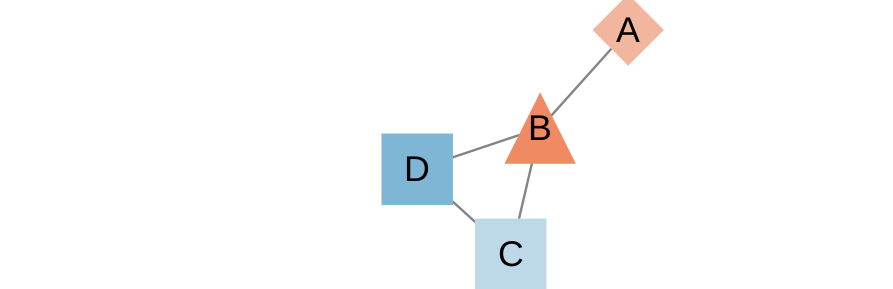

In [41]:
p4c.notebook_export_show_image()

### Selecionando nós

Usando como exemplo a rede anterior, selecionarei o nó C pelo nome

In [61]:
p4c.select_nodes('C', 'name')

{'nodes': [326], 'edges': []}

In [62]:
p4c.get_selected_nodes()

['C']

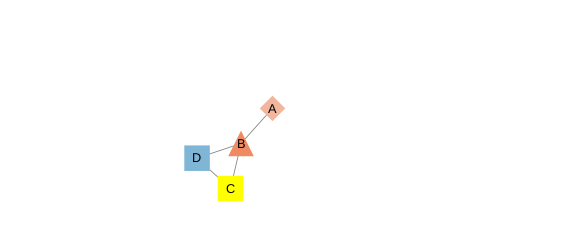

In [63]:
p4c.notebook_export_show_image()

Da pra selecionar os primeiros vizinhos do nó ja selecionado

In [64]:
p4c.select_first_neighbors()

{'nodes': [323, 326, 329], 'edges': []}

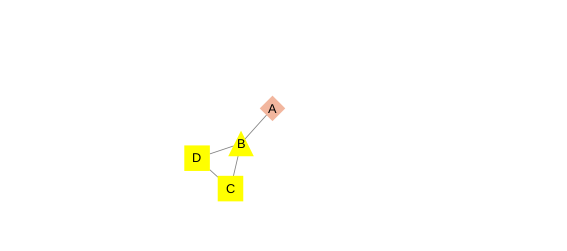

In [65]:
p4c.notebook_export_show_image()

converter os nós selecionados para uma lista python

In [66]:
node_names = p4c.get_selected_nodes()

In [67]:
node_names

['B', 'C', 'D']

para limpar a seleção:

In [68]:
p4c.clear_selection()

''

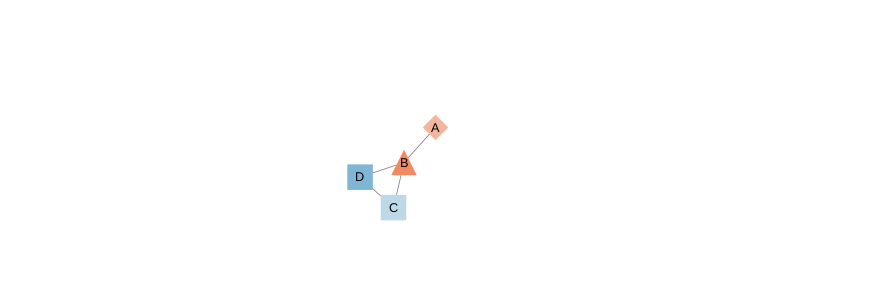

In [69]:
p4c.notebook_export_show_image()